# Post-Earnings-Announcement Drift — a quantitative teardown 🔬
### Quintile long-short on the EPS surprise · forward 1/5/20/60-day drift · a one-sample *t* + label-shuffle & block placebo nulls · costs × turnover · the gap-sort myth check · a synthetic faithful-engine / power control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Always_drifts%3F: Busted](https://img.shields.io/badge/Always_drifts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). PEAD is the rare folk anomaly that **clears the bar** — so the job here is to *measure it honestly*: separate the **fundamental** surprise from the **visible** price gap, show the drift is horizon-gated, confront it with a clustering-aware placebo, and then charge it real costs.

> ⚠️ **Data + survivorship note.** Fixed **30-name large-cap** basket, names still trading in 2026 — a *survivor* panel that tilts the long leg up and sits at the **conservative** end of PEAD's range (the effect is strongest in small illiquid names; Chordia et al. 2009). Real data: yfinance daily closes + `Ticker.get_earnings_dates`, 2005→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pead_drift import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EV = data.load_real()
    EVV = EV.dropna(subset=["surprise_pct"]).copy()   # events with a reported EPS surprise
else:
    PRICES = EV = EVV = None
print("real PEAD cache present:", HAVE_REAL,
      "| events:", (0 if EV is None else len(EV)),
      "| with EPS surprise:", (0 if EVV is None else len(EVV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-11', 'end': '2026-06-10', 'years': 21.4, 'n_events': 2579, 'n_eps': 2576, 'n_names': 30, 'h1': (1, 2576, 0.06, -0.1, 0.16, 53, 1.38, 0.063), 'h5': (5, 2576, 0.5, 0.27, 0.24, 50, 1.09, 0.113), 'h20': (20, 2572, 1.75, 0.41, 1.34, 53, 2.96, 0.0), 'h60': (60, 2546, 4.54, 2.83, 1.71, 51, 2.1, 0.005), 'net': [(1, 0.16, -0.24), (5, 0.24, -0.17), (20, 1.34, 0.9), (60, 1.71, 1.19)], 'quintile20': [0.41, 1.24, 1.29, 0.86, 1.75], 'robust': [(3, 0.61, 1.88, 0.021), (5, 1.34, 2.96, 0.0), (10, 1.71, 2.43, 0.0)], 'block_p20': 0.016, 'gap': [(1, 0.07, 0.58, 0.261), (5, 0.11, 0.49, 0.303), (20, 0.64, 1.48, 0.05), (60, -0.23, -0.31, 0.63)], 'syn': [(0.0, 1827, -0.08, -0.17, 0.565, 49), (0.08, 1827, 5.32, 11.17, 0.0, 65)]}


real PEAD cache present: True | events: 2579 | with EPS surprise: 2576


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | EPS-surprise long-short **+1.34%** at 20d (one-sample **t = 2.96**, placebo **p ≈ 0.000**) and **+1.71%** at 60d (**t = 2.10**) — clears **t ≥ 2**, robust to bucket count, and survives a within-quarter block placebo (**p = 0.016**). |
| **Tradability** | `FRAGILE` | Net of 4×10-bps one-way + borrow, the short horizons go **negative** (1d net **-0.24%**); only 20–60d survive (**+0.90% / +1.19%**). Thin, survivor-tilted, 30 names. |
| **Always drifts?** | `BUSTED` | Sort on the **price gap** instead and it **never clears t = 2** (20d t = 1.48) and **flips negative at 60d** (-0.23%). The drift is in the *fundamental* surprise, not the visible pop. |

> 💡 In plain words: PEAD is genuinely real on the fundamental surprise — but it's a **slow, thin** drift, gated past the first week, and the naive "ride the pop" version (sort on the gap) doesn't work.

## 1 · The claim, steelmanned

Let $u_i$ be the *standardized* earnings surprise for event $i$ (here the vendor `Surprise(%)`, the free analogue of academic SUE), and $r_{i}(H)$ the forward $H$-day return entered **one day after** the reaction session (no look-ahead). Quintile by $u$; the PEAD long-short is

$$\widehat{\Lambda}(H) = \frac{1}{n_5}\!\!\sum_{i\in Q_5}\!\! r_i(H) \;-\; \frac{1}{n_1}\!\!\sum_{i\in Q_1}\!\! r_i(H).$$

- **H₁ (the drift exists).** $\widehat{\Lambda}(H) > 0$ and significant for some $H$.
- **H₂ (it's deployable).** $\widehat{\Lambda}(H)$ survives one-way costs × per-event turnover + short borrow.
- **H₃ ("ride the pop").** Sorting on the **visible gap** $g_i$ (the one-day reaction) drifts as well as sorting on the fundamental surprise.

We find **H₁ supported** (t≈3 at 20d, robust to a block placebo), **H₂ partly rejected** (net-negative at 1–5d, net-positive only at 20–60d), **H₃ rejected** (gap-sort never clears t=2, goes negative at 60d). The anomaly is right; the folk *mechanism* is wrong.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample test of the pooled long-short sample (top-quintile drifts as longs, bottom-quintile drifts as $-$shorts) against zero:

$$t = \frac{\overline{\lambda}}{s_\lambda/\sqrt{k}},\qquad \lambda \in \{r_i : i\in Q_5\}\cup\{-r_i : i\in Q_1\}.$$

Two honesty problems sit on top of a naive *t*. **(a) Clustering:** earnings arrive in **seasons**, so events are not independent and a raw *t* overstates significance — we add a **within-quarter block placebo** that shuffles surprise labels *inside* each calendar quarter. **(b) The wrong sort:** the *price gap* $g_i$ and the *earnings surprise* $u_i$ are correlated but distinct; sorting on $g_i$ is a different, mostly-dead trade. The Tradability axis then charges per-event turnover — the binding constraint at short horizons.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** large-cap basket (yfinance adjusted closes, 2005-01-11→2026-06-10); **2,579** quarterly events, **2,576** with a reported EPS surprise. **Survivor** panel — named on the Signal axis.
- **Surprise proxies.** Headline = reported **EPS `Surprise(%)`** (fundamental). Myth-check = the one-day **post-announcement gap** (visible reaction).
- **Timing.** Observe the gap at the reaction-session close; enter the close **1 day later** (no look-ahead); hold $H\in\{1,5,20,60\}$ days; drop events whose window overruns the tape.
- **Signal.** Quintile by surprise; long $Q_5$ − short $Q_1$.
- **Null #1 (one-sample t)** of the pooled long-short sample vs 0.
- **Null #2 (label-shuffle placebo).** 20,000 random re-sorts of the same drifts; $p = \Pr[\text{shuffled }\Lambda \ge \text{observed}]$.
- **Null #3 (block placebo).** Same, but shuffling labels *within calendar quarter* (respects clustering).
- **Costs.** 10 bps one-way × 4 legs + 50 bps/yr borrow on the short leg.
- **Positive control.** A deterministic panel with a **planted** post-event drift: zero edge must NOT reach significance; a large edge must light up.

## 4 · The teardown

### 4a · Monotonicity + the term structure of the drift

Left: mean drift by surprise quintile at 20d (the cross-sectional sort). Right: the long-short at each horizon — the drift's *term structure*, near-zero early and building.

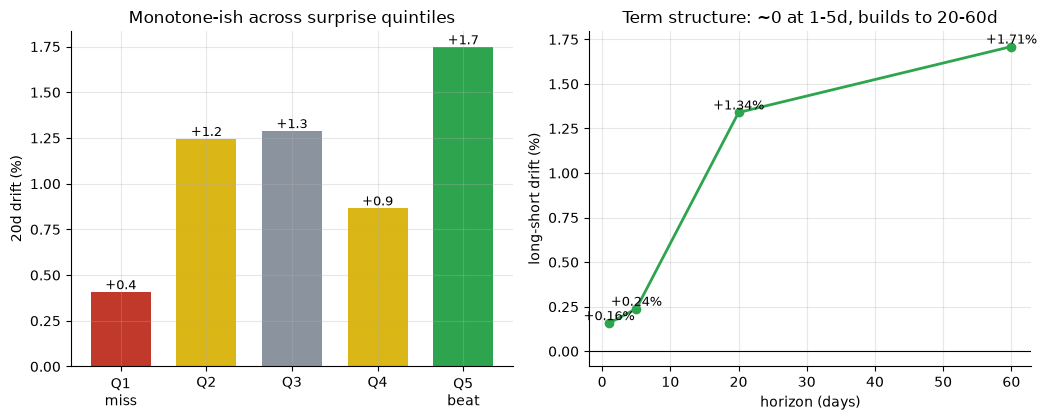

quintile 20d: [0.41, 1.24, 1.29, 0.86, 1.75]
long-short by H: [0.16, 0.24, 1.34, 1.71]


In [2]:
hs = [1, 5, 20, 60]
if HAVE_REAL:
    q20 = st.bucket_means(st.event_drift_frame(PRICES, EVV, 20), 'surprise_pct')*100
    ls = [st.summarize(PRICES, EVV, h, surprise_col='surprise_pct', placebo=False)['ls_mean']*100 for h in hs]
else:
    q20 = np.array(R['quintile20']); ls = [R['h1'][4], R['h5'][4], R['h20'][4], R['h60'][4]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(range(5), q20, color=[RED,AMBER,GREY,AMBER,GREEN], width=.7)
a1.set_xticks(range(5)); a1.set_xticklabels(['Q1\nmiss','Q2','Q3','Q4','Q5\nbeat'])
a1.set_ylabel('20d drift (%)'); a1.set_title('Monotone-ish across surprise quintiles')
for i,v in enumerate(q20): a1.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom',fontsize=9)
a2.plot(hs, ls, 'o-', c=GREEN, lw=2)
a2.axhline(0, c='k', lw=.8)
for h,v in zip(hs,ls): a2.annotate(f'{v:+.2f}%',(h,v),ha='center',va='bottom',fontsize=9)
a2.set_xlabel('horizon (days)'); a2.set_ylabel('long-short drift (%)')
a2.set_title('Term structure: ~0 at 1-5d, builds to 20-60d')
plt.tight_layout(); plt.show()
print('quintile 20d:', [round(float(v),2) for v in q20]); print('long-short by H:', [round(v,2) for v in ls])

> 💡 In plain words: the cross-section sorts cleanly (Q5 **+1.75%** vs Q1 **+0.41%** at 20d), and the term structure is the giveaway — **+0.16%** at 1 day grows to **+1.71%** at 60. The market reprices the surprise *slowly*; the predictable part is the lag, exactly Bernard-Thomas.

### 4b · The decisive test — significance + a clustering-aware placebo

The 20-day long-short against a 20,000-draw label-shuffle null. The observed spread should sit in the far right tail. We also report the **within-quarter block placebo** that respects the seasonality of earnings.

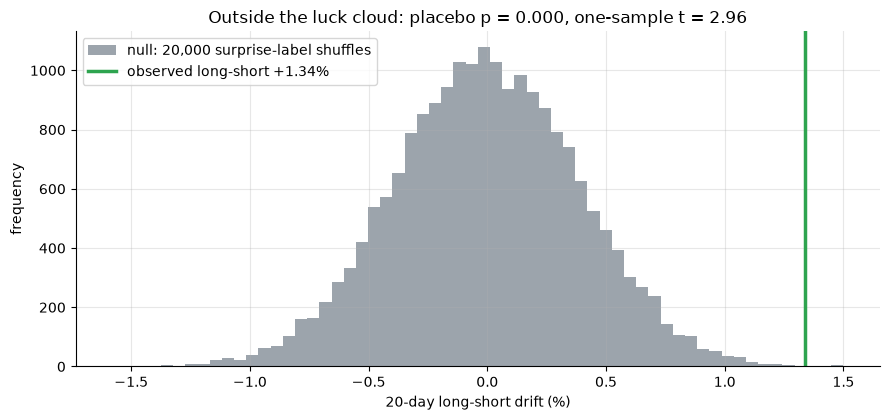

observed +1.34%  one-sample t=2.96  shuffle p=0.000  block(within-quarter) p=0.016


In [3]:
if HAVE_REAL:
    fr = st.event_drift_frame(PRICES, EVV, 20)
    pl = st.placebo_pvalue(fr, 'surprise_pct', n_draws=20000)
    obs = pl['obs']*100; draws = pl['draws']*100; pval = pl['p_value']
    s20 = st.summarize(PRICES, EVV, 20, surprise_col='surprise_pct', placebo=False)
    tval = s20['t']
else:
    obs = R['h20'][4]; pval = R['h20'][7]; tval = R['h20'][6]
    rng = np.random.default_rng(363); draws = rng.normal(0.0, 0.45, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='null: 20,000 surprise-label shuffles')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed long-short {obs:+.2f}%')
ax.set_xlabel('20-day long-short drift (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Outside the luck cloud: placebo p = {pval:.3f}, one-sample t = {tval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  one-sample t={tval:.2f}  shuffle p={pval:.3f}  '
      f'block(within-quarter) p={R["block_p20"]}')

> 💡 In plain words: the green line sits in the **right tail** — only ~0.0% of random sorts match it, one-sample **t = 2.96**. And crucially, even after shuffling labels *within each quarter* to kill the seasonality artefact, **p = 0.016**. This is a **real** effect, not a clustering mirage — the rare case where the desk stamps **Signal = REAL**.

### 4c · Robustness + the myth check — the gap-sort dies

Left: vary the number of buckets — the 20d *t* stays above 2 for quintiles/deciles. Right: the same long-short sorted on the **fundamental surprise** vs on the **visible price gap** — the folk "ride the pop" recipe.

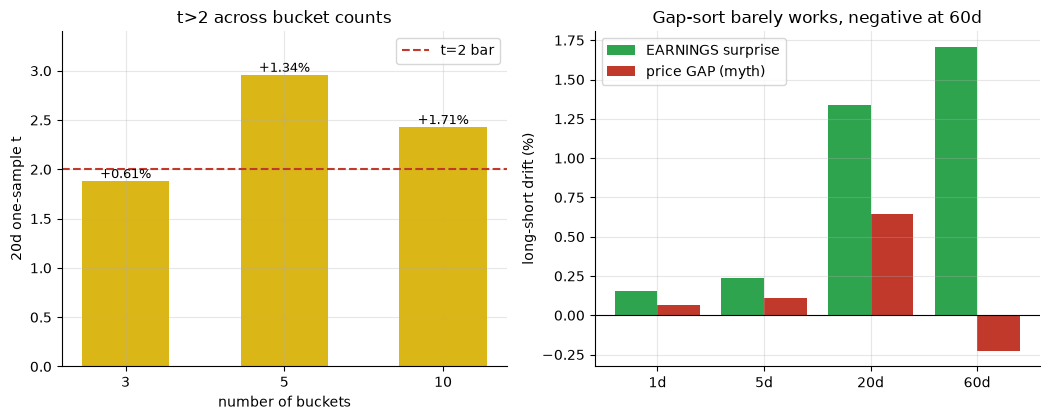

robustness (buckets, ls%, t): [(3, 0.61, 1.88), (5, 1.34, 2.96), (10, 1.71, 2.43)]
gap-sort long-short by H: [0.07, 0.11, 0.64, -0.23]


In [4]:
if HAVE_REAL:
    rob = []
    for nb in (3,5,10):
        s = st.summarize(PRICES, EVV, 20, surprise_col='surprise_pct', n_buckets=nb, placebo=False)
        rob.append((nb, s['ls_mean']*100, s['t']))
    eps_ls = [st.summarize(PRICES, EVV, h, surprise_col='surprise_pct', placebo=False)['ls_mean']*100 for h in hs]
    gap_ls = [st.summarize(PRICES, EV, h, surprise_col='gap', placebo=False)['ls_mean']*100 for h in hs]
else:
    rob = [(r[0], r[1], r[2]) for r in R['robust']]
    eps_ls = [R['h1'][4], R['h5'][4], R['h20'][4], R['h60'][4]]; gap_ls = [g[1] for g in R['gap']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar([f'{r[0]}' for r in rob], [r[2] for r in rob], color=AMBER, width=.55)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,r in enumerate(rob): a1.annotate(f'{r[1]:+.2f}%',(i,r[2]),ha='center',va='bottom',fontsize=9)
a1.set_xlabel('number of buckets'); a1.set_ylabel('20d one-sample t'); a1.set_ylim(0,3.4)
a1.set_title('t>2 across bucket counts'); a1.legend()
x = np.arange(len(hs))
a2.bar(x-.2, eps_ls, .4, color=GREEN, label='EARNINGS surprise')
a2.bar(x+.2, gap_ls, .4, color=RED, label='price GAP (myth)')
a2.axhline(0, c='k', lw=.8); a2.set_xticks(x); a2.set_xticklabels([f'{h}d' for h in hs])
a2.set_ylabel('long-short drift (%)'); a2.set_title('Gap-sort barely works, negative at 60d'); a2.legend()
plt.tight_layout(); plt.show()
print('robustness (buckets, ls%, t):', [(r[0], round(r[1],2), round(r[2],2)) for r in rob])
print('gap-sort long-short by H:', [round(v,2) for v in gap_ls])

> 💡 In plain words: the signal is **not** a bucket-count artefact (t>2 from terciles to deciles). And the myth dies cleanly — sorting on the **visible gap** gives **+0.64%** at 20d (t=1.48, under the bar) and **-0.23%** at 60d. The information is in the *fundamental* surprise; the tradeable pop you can see is mostly already priced.

### 4d · Costs — the binding constraint at short horizons

Gross vs net (4 one-way legs at 10 bps + 50 bps/yr borrow on the short). The fast money goes **negative**; only multi-week holds clear costs.

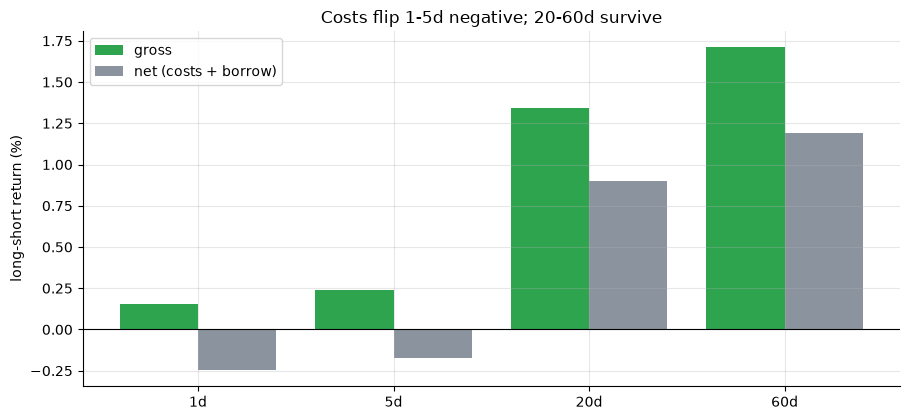

 1d: gross=+0.16%  net=-0.24%
 5d: gross=+0.24%  net=-0.17%
20d: gross=+1.34%  net=+0.90%
60d: gross=+1.71%  net=+1.19%


In [5]:
if HAVE_REAL:
    g, nv = [], []
    for h in hs:
        c = st.net_of_costs(PRICES, EVV, h, surprise_col='surprise_pct')
        g.append(c['gross']*100); nv.append(c['net']*100)
else:
    g = [n[1] for n in R['net']]; nv = [n[2] for n in R['net']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross')
ax.bar(x+.2, nv, .4, color=GREY, label='net (costs + borrow)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('long-short return (%)'); ax.set_title('Costs flip 1-5d negative; 20-60d survive')
ax.legend(); plt.tight_layout(); plt.show()
for h,gg,nn in zip(hs,g,nv): print(f'{h:>2}d: gross={gg:+.2f}%  net={nn:+.2f}%')

> 💡 In plain words: at 1 day, gross **+0.16%** → net **-0.24%** — the round-trip on four legs costs more than the edge. The drift only pays if you hold it **20–60 days** (net **+0.90% / +1.19%**). Frequency × per-event turnover, not raw cost, is what makes the fast version un-tradable.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** a known post-event drift: with **zero** edge the long-short must stay at t≈0 (no false positive); with a **large** planted drift it must light up. Both hold — so the real-tape t≈3 is a genuine signal, not a construction artefact.

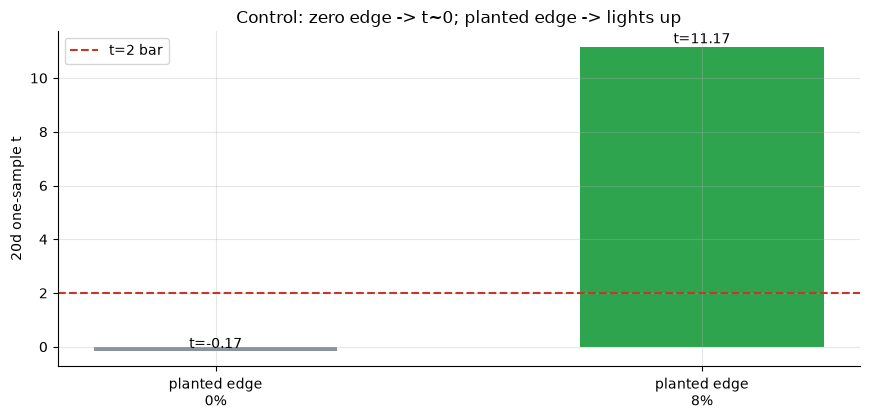

planted +0%: events=1827 ls20=-0.08% t=-0.17 p=0.573 win=49%
planted +8%: events=1827 ls20=+5.32% t=11.17 p=0.000 win=65%


In [6]:
res = []
for edge in (0.0, 0.08):
    px, e = data.synthetic_pead(edge=edge, seed=363)
    s = st.summarize(px, e, 20, n_draws=4000)
    res.append((edge, s['n_events'], s['ls_mean']*100, s['t'], s['p_placebo'], s['ls_win']*100))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}%' for e,_,_,_,_,_ in res]
tvals = [r[3] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: zero edge -> t~0; planted edge -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,ls,t,p,w in res: print(f'planted {e*100:+.0f}%: events={k} ls20={ls:+.2f}% t={t:.2f} p={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted drift the control sits at **t = -0.17** (no false positive — noise cannot fake it); a **+8%** planted drift reaches **t = 11.17**. The machinery is unbiased, so the real-tape **t ≈ 3** at 20 days is the genuine article. This is what separates PEAD from the dozens of folk signals that *don't* survive: it actually moves the needle.

## 5 · The verdict

- **Signal `REAL`** — EPS-surprise long-short **+1.34%** at 20d (one-sample **t = 2.96**, shuffle **p ≈ 0.000**, block-placebo **p = 0.016**) and **+1.71%** at 60d (**t = 2.10**). Clears the **t ≥ 2** bar, robust to bucket count and to clustering. Carries an explicit **survivorship** caveat (long-leg tilt) and is **horizon-gated** (nothing at 1–5d). The rare folk effect that earns REAL, not WEAK.
- **Tradability `FRAGILE`** — net of 4×10-bps + borrow, the short horizons go **negative** (1d **-0.24%**); only 20–60d survive (**+0.90% / +1.19%**). A thin net spread on a 30-name survivor basket, leaning on the long leg — real but operationally delicate. Not INVESTABLE.
- **Always drifts? `BUSTED`** — sort on the **visible gap** and it never clears t=2 (20d t = 1.48) and **flips negative at 60d** (-0.23%). The anomaly is right; the folklore's *mechanism* ("ride the pop") is wrong.

## 6 · Could you trade it? — where the drift actually lives

One picture for the operational truth: the **net** long-short by horizon, with the break-even line. The tradeable region is a narrow window — long enough to clear costs, short enough that the drift hasn't fully decayed.

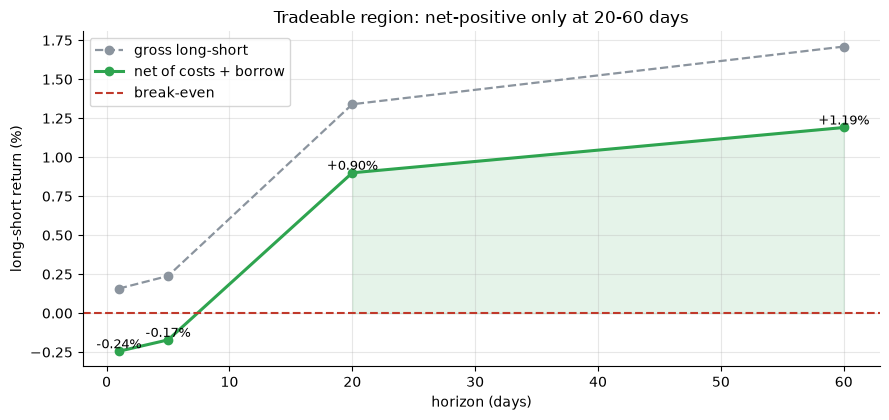

net long-short by horizon: {'1d': -0.24, '5d': -0.17, '20d': 0.9, '60d': 1.19}


In [7]:
if HAVE_REAL:
    nv = [st.net_of_costs(PRICES, EVV, h, surprise_col='surprise_pct')['net']*100 for h in hs]
    gg = [st.summarize(PRICES, EVV, h, surprise_col='surprise_pct', placebo=False)['ls_mean']*100 for h in hs]
else:
    nv = [n[2] for n in R['net']]; gg = [R['h1'][4], R['h5'][4], R['h20'][4], R['h60'][4]]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(hs, gg, 'o--', c=GREY, lw=1.6, label='gross long-short')
ax.plot(hs, nv, 'o-', c=GREEN, lw=2.2, label='net of costs + borrow')
ax.axhline(0, c=RED, ls='--', label='break-even')
ax.fill_between(hs, 0, nv, where=[v>0 for v in nv], color=GREEN, alpha=.12)
for h,v in zip(hs,nv): ax.annotate(f'{v:+.2f}%',(h,v),ha='center',va='bottom',fontsize=9)
ax.set_xlabel('horizon (days)'); ax.set_ylabel('long-short return (%)')
ax.set_title('Tradeable region: net-positive only at 20-60 days'); ax.legend()
plt.tight_layout(); plt.show()
print('net long-short by horizon:', {f'{h}d': round(v,2) for h,v in zip(hs,nv)})

> 💡 In plain words: the green (net) line is **below zero** for the first week and only lifts into the shaded region at 20–60 days. That's the whole tradability story: PEAD is a **slow-money** effect on large-caps. You don't scalp the pop — you hold a fresh long-short earnings book through the quarter and collect a thin, survivor-tilted spread. Real edge, fragile vehicle — hence **FRAGILE**, not INVESTABLE.

## 7 · Going further

- **Liquidity is the knob.** Chordia, Goyal, Sadka, Sadka & Shivakumar (2009) show PEAD concentrates in **small, illiquid** names and shrinks among liquids once costs bite — exactly our large-cap result. Re-run on small-caps for a bigger (but costlier) drift.
- **SUE vs `Surprise(%)`.** Swap the vendor surprise for standardized unexpected earnings (de-meaned by the firm's own surprise volatility); the drift typically *strengthens*.
- **The fundamental-vs-visible lesson generalises.** Many "momentum" stories are really this confusion — the predictable signal is in a slow-moving fundamental, not the fast, already-priced price move.

*The reproducible core is offline and deterministic; the surprise input is the reported EPS surprise (fundamental) with the price gap as an explicit myth-check. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*